# Step 14: Matched Actual Expenditure

**Hypothesis:** Mixed schedules benefit from removing more total index or removing it at different times.

Run six schedules at the original ceiling. Set a common smaller ceiling to 90% of the lowest observed expenditure, then rerun all six schedules (12 simulations). **Verify that all six actually spend the matched amount.** Fixed unit cost also matches total removed index. Compare trajectories and early removal. Change STEPS to 260 for a separate longer-horizon check.

In [1]:
# Resolve the repository from this notebook's directory or the repository root.
from pathlib import Path
import os
import sys
_start = Path.cwd().resolve()
repo_root = next(p for p in (_start, *_start.parents) if (p / "src" / "weed_ca.py").is_file())
os.chdir(repo_root)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from pathlib import Path
import os
from dataclasses import replace
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

current = Path.cwd().resolve()
repo_root = next(p for p in (current, *current.parents) if (p / "src").is_dir())
os.chdir(repo_root)
from utils.data_loader import load_locality_data
from src.weed_experiment import ExperimentConfig, run_experiment
from src.experiment_schedules import (
    PolicyParameters, ScheduledPolicy, BudgetLimitedPolicy,
    make_scheduled_policy, standard_schedules, budget_exhaustion_step,
)

SAMPLE_ID = 2036
STEPS = 100  # Change to 260 to inspect a longer horizon.
row = pd.read_csv(repo_root / "results/strong_parrondo_finalists.csv").set_index("sample_id").loc[SAMPLE_ID]
budget = float(row.budget) * STEPS / 100
parameters = PolicyParameters(
    a_rate=float(row.a_rate), b_rate=float(row.b_rate),
    max_cells=int(row.max_cells), boundary=float(row.boundary),
    b_lower=float(row.b_lower), unit_cost=200.0,
)
config = ExperimentConfig(steps=STEPS, growth_rate=float(row.growth_rate), diffusion_rate=float(row.diffusion_rate))
localities = load_locality_data(repo_root / "data")
metro = localities[localities.postcode.astype(int).between(6000, 6199)].copy()
schedules = standard_schedules(STEPS)
print(f"Candidate {SAMPLE_ID}; steps={STEPS}; budget ceiling={budget:,.0f}")


Candidate 2036; steps=100; budget ceiling=250,000


C:\Users\kazut\Documents\ChatGPT\cits4403_computational_model\src\data_loader.py:28: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  census["postcode"] = (


,sample_id,steps,setting,strategy,budget_ceiling,final_cost,total_removed_index,first_half_removed_index,relative_change,cumulative_mean_weed,budget_exhaustion_step,matched_expenditure_verified
0,2036,100,original ceiling,A only,250000.0000,149107.484375,745.537422,374.279297,0.041958,87.949112,NaN,True
1,2036,100,original ceiling,B only,250000.0000,199967.171875,999.835859,492.734805,0.014206,86.396667,NaN,True
2,2036,100,original ceiling,AB,250000.0000,228212.656250,1141.063281,567.924531,-0.002064,85.803925,NaN,True
3,2036,100,original ceiling,BA,250000.0000,229166.359375,1145.831797,567.860469,-0.003486,85.672371,NaN,True
4,2036,100,original ceiling,A block B,250000.0000,138087.875000,690.439375,374.279297,0.047051,87.685555,NaN,True
5,2036,100,original ceiling,B block A,250000.0000,173466.421875,867.332109,492.734805,0.029926,86.752548,NaN,True
6,2036,100,matched expenditure,A only,124279.0875,124279.085938,621.395430,374.279297,0.060456,88.089020,84.0,True
7,2036,100,matched expenditure,B only,124279.0875,124279.085938,621.395430,492.734805,0.063402,87.250999,64.0,True
8,2036,100,matched expenditure,AB,124279.0875,124279.085938,621.395430,567.924531,0.064603,87.182671,56.0,True
9,2036,100,matched expenditure,BA,124279.0875,124279.085938,621.395430,567.860469,0.063470,87.079628,55.0,True


Matched ceiling: 124,279.09; actual expenditure matched: True


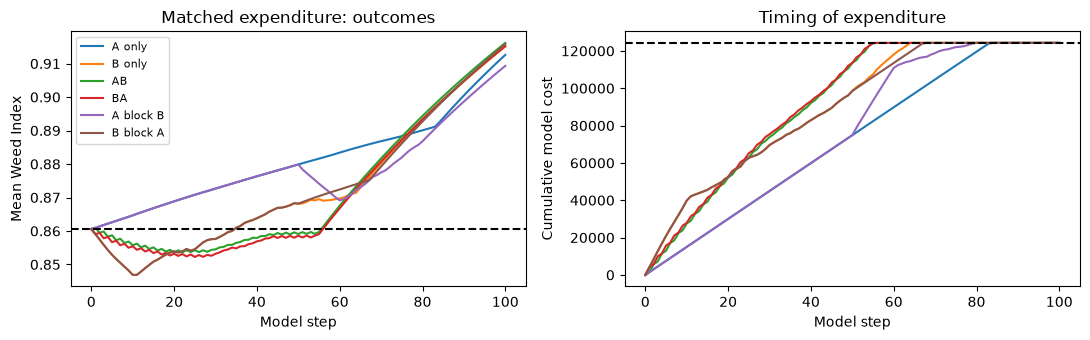

In [2]:
MATCH_FRACTION = 0.90  # Lower this if some schedules do not reach the common ceiling.
pilot = {}
for strategy, schedule in schedules.items():
    pilot[strategy] = run_experiment(strategy, metro, config, make_scheduled_policy(schedule, parameters, budget))
matched_budget = MATCH_FRACTION * min(result.final_cost for result in pilot.values())
if matched_budget <= 0:
    raise RuntimeError("At least one pilot spends zero; positive matched expenditure is unavailable.")

matched = {}
for strategy, schedule in schedules.items():
    matched[strategy] = run_experiment(strategy, metro, config, make_scheduled_policy(schedule, parameters, matched_budget))
matched_ok = all(np.isclose(result.final_cost, matched_budget, rtol=0, atol=0.05) for result in matched.values())
rows = []
for setting, runs, ceiling in (("original ceiling", pilot, budget), ("matched expenditure", matched, matched_budget)):
    for strategy, result in runs.items():
        rows.append({"sample_id": SAMPLE_ID, "steps": STEPS, "setting": setting, "strategy": strategy,
            "budget_ceiling": ceiling, "final_cost": result.final_cost,
            "total_removed_index": result.final_cost / parameters.unit_cost,
            "first_half_removed_index": float(result.cost_history[STEPS // 2]) / parameters.unit_cost,
            "relative_change": result.relative_change,
            "cumulative_mean_weed": float(np.trapezoid(result.mean_weed)),
            "budget_exhaustion_step": budget_exhaustion_step(result.cost_history, ceiling)})
summary = pd.DataFrame(rows)
summary["matched_expenditure_verified"] = matched_ok
display(summary.round(6))
summary.to_csv(repo_root / "results/step14_matched_expenditure_summary.csv", index=False)
print(f"Matched ceiling: {matched_budget:,.2f}; actual expenditure matched: {matched_ok}")
if not matched_ok:
    raise RuntimeError("Actual expenditure is not matched. Lower MATCH_FRACTION and rerun this cell before interpreting the comparison.")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for strategy, result in matched.items():
    axes[0].plot(result.mean_weed, label=strategy)
    axes[1].plot(result.cost_history, label=strategy)
axes[0].axhline(next(iter(matched.values())).initial_mean, color="black", linestyle="--")
axes[1].axhline(matched_budget, color="black", linestyle="--")
axes[0].set(xlabel="Model step", ylabel="Mean Weed Index", title="Matched expenditure: outcomes")
axes[1].set(xlabel="Model step", ylabel="Cumulative model cost", title="Timing of expenditure")
axes[0].legend(fontsize=8)
fig.tight_layout()
plt.show()


## Observed results: candidate 2036, 100 steps

Actual expenditure was successfully matched: all six schedules spent approximately **124,279.09**, corresponding to **621.40** removed index units at unit cost 200.

At the original 250,000 ceiling, AB and BA improved the mean by **0.206%** and **0.349%**, whereas both single-policy and block schedules worsened it. None of the original-ceiling runs exhausted its budget.

Under matched lower expenditure, **all six schedules worsened the final mean**. AB increased it by **6.460%** and BA by **6.347%**; the other schedules ranged from **5.665% to 6.420%**. The strict reversal disappeared, and AB/BA no longer had the lowest final index. A block B had the lowest final index among these matched runs.

Budget timing differed substantially: AB and BA exhausted the common ceiling at steps **56 and 55**, compared with **84 for A only**, **64 for B only**, **80 for A block B**, and **68 for B block A**. Thus, AB/BA spent earlier and then experienced a longer period without treatment.

The outcome also depends on the metric: BA had the lowest cumulative mean weed burden (**87.080**), followed by AB (**87.183**), even though neither had the best final index. Earlier treatment can improve the trajectory while leaving a worse endpoint after early exhaustion.

**Interpretation:** The original endpoint reversal did not survive this matched-expenditure, lower-budget test. Treatment volume and spending timing are plausible contributors. However, lowering the ceiling changes the intervention and forces exhaustion, so this does not prove that greater total spending alone caused the original reversal. Timing and spatial targeting remain intertwined.

The verification flag refers to matching within the lower-budget group; the original-ceiling group did not have equal actual expenditure. These results cover candidate 2036 at 100 steps, not the longer Step10 horizons.